In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")
plt.rcParams["font.family"] = "DejaVu Sans"

In [3]:
DATA_PATH = "data/CIC_IDS2017_sampled.csv"

RANDOM_STATE = 42
VAL_SIZE = 0.2
PERCENTILE = 98

In [4]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Original shape:", df.shape)
df.head()

Original shape: (566195, 81)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,is_attack
0,40474,7182757,1,5,6,30,6,6,6.0,0.000000,6,6,6.000000,0.00000,5.012003,0.835334,1.436551e+06,3.186980e+06,7137556,0,0,0.00000,0.000000e+00,0,0,7164811,1791202.75,3.564259e+06,7137556,0,0,0,0,0,20,100,0.139222,0.696112,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,5,7.000000,6.0,6.000000,20,0,0,0,0,0,0,1,6,5,30,229,0,0,20,45201.000,0.000,45201,45201,7137556.0,0.00,7137556,7137556,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
1,28907,938509,1,5,6,30,6,6,6.0,0.000000,6,6,6.000000,0.00000,38.358716,6.393119,1.877018e+05,4.098531e+05,920834,6,0,0.00000,0.000000e+00,0,0,929015,232253.75,4.590645e+05,920834,6,0,0,0,0,20,100,1.065520,5.327599,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,5,7.000000,6.0,6.000000,20,0,0,0,0,0,0,1,6,5,30,229,0,0,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
2,0,119995732,123,0,0,0,0,0,0.0,0.000000,0,0,0.000000,0.00000,0.000000,1.025036,9.835716e+05,3.395926e+06,26300000,0,120000000,983571.57380,3.395926e+06,26300000,0,0,0.00,0.000000e+00,0,0,0,0,0,0,0,0,1.025036,0.000000,0,0,0.000000,0.000000,0.0000,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.000000,0,0,0,0,0,0,0,123,0,0,0,-1,-1,0,0,3753432.167,5183854.063,13200000,1,13100000.0,6507819.26,26300000,6484077,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
3,443,142954,10,6,553,3949,196,0,55.3,71.704719,2860,0,658.166667,1111.62915,31492.647980,111.924115,9.530267e+03,1.529768e+04,37502,3,142954,15883.77778,1.769110e+04,39066,49,85183,17036.60,2.273564e+04,45741,3,0,0,0,0,212,132,69.952572,41.971543,0,2860,264.823529,692.022239,478894.7794,0,0,0,1,0,0,0,0,0,281.375000,55.3,658.166667,212,0,0,0,0,0,0,10,553,6,3949,8192,343,9,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0
4,17541,2548725,1,6,6,36,6,6,6.0,0.000000,6,6,6.000000,0.00000,16.478828,2.746471,4.247875e+05,1.036908e+06,2541367,1,0,0.00000,0.000000e+00,0,0,2546294,509258.80,1.135983e+06,2541367,1,0,0,0,0,20,120,0.392353,2.354118,6,6,6.000000,0.000000,0.0000,0,0,0,0,1,1,0,0,6,6.857143,6.0,6.000000,20,0,0,0,0,0,0,1,6,6,36,229,0,0,20,0.000,0.000,0,0,0.0,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0


In [5]:
label_candidates = [c for c in df.columns if c.lower() == "label"]

if len(label_candidates) == 0:
    raise ValueError("Label column was not found.")

label_col = label_candidates[0]
print("Label column:", label_col)

df[label_col] = df[label_col].astype(str)
df[label_col] = df[label_col].str.replace("�", "-", regex=False)
df[label_col] = df[label_col].str.strip()

# target: 0 = BENIGN, 1 = útok
df["target"] = (df[label_col] != "BENIGN").astype(int)

print("Target distribution:")
print(df["target"].value_counts())

Label column: Label
Target distribution:
target
0    454616
1    111579
Name: count, dtype: int64


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c.lower() != "target"
    and "label" not in c.lower()
    and "attack" not in c.lower()
]

removed_cols = [c for c in numeric_cols if c not in feature_cols]

print("All numeric columns:", len(numeric_cols))
print("Feature columns used for modeling:", len(feature_cols))
print("Removed columns:", removed_cols)

All numeric columns: 80
Feature columns used for modeling: 78
Removed columns: ['is_attack', 'target']


In [7]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

before_drop = df.shape[0]
df = df.dropna(subset=feature_cols).reset_index(drop=True)
after_drop = df.shape[0]

print(f"Rows removed during cleaning: {before_drop - after_drop}")
print("Cleaned shape:", df.shape)

Rows removed during cleaning: 562
Cleaned shape: (565633, 82)


In [8]:
X = df[feature_cols].copy()
y = df["target"].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (565633, 78)
y shape: (565633,)
Class distribution: [454277 111356]


In [9]:
normal_mask = (y == 0)

X_normal = X.loc[normal_mask].copy()

X_train, X_val = train_test_split(
    X_normal,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_test = X.copy()
y_test = y.copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (363421, 78)
X_val shape: (90856, 78)
X_test shape: (565633, 78)
y_test shape: (565633,)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (363421, 78)
Scaled val shape: (90856, 78)
Scaled test shape: (565633, 78)


In [11]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

model.fit(X_train_scaled)
print("One-Class SVM trained successfully.")

One-Class SVM trained successfully.


In [12]:
scores_val = -model.decision_function(X_val_scaled)
scores_test = -model.decision_function(X_test_scaled)

print("Validation score range:", scores_val.min(), scores_val.max())
print("Test score range:", scores_test.min(), scores_test.max())

Validation score range: -476.5163328233805 619.360980222024
Test score range: -493.7308810636721 619.360980222024


In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

PERCENTILES = [99, 98, 95, 90, 85, 80, 70, 60, 50]

results = []

for p in PERCENTILES:
    threshold = np.percentile(scores_val, p)
    y_pred_p = (scores_test >= threshold).astype(int)

    acc_p = accuracy_score(y_test, y_pred_p)
    prec_p = precision_score(y_test, y_pred_p, zero_division=0)
    rec_p = recall_score(y_test, y_pred_p, zero_division=0)
    f1_p = f1_score(y_test, y_pred_p, zero_division=0)

    results.append({
        "Percentil": p,
        "Threshold": threshold,
        "Precision": prec_p,
        "Recall": rec_p,
        "F1-score": f1_p,
        "Accuracy": acc_p,
        "AUC": roc_auc,
        "Predicted anomalies": int(y_pred_p.sum())
    })

results_df = pd.DataFrame(results)
results_df

,Percentil,Threshold,Precision,Recall,F1-score,Accuracy,AUC,Predicted anomalies
0,99,391.153999,0.905595,0.393935,0.549038,0.872599,0.733874,48440
1,98,227.390284,0.843900,0.430673,0.570301,0.872233,0.733874,56829
2,95,0.011368,0.693606,0.456410,0.550547,0.853292,0.733874,73275
3,90,-60.600552,0.544265,0.488766,0.515024,0.818782,0.733874,100001
4,85,-111.659202,0.449693,0.498339,0.472768,0.781180,0.733874,123402
5,80,-162.430380,0.380720,0.501203,0.432732,0.741302,0.733874,146596
6,70,-231.476055,0.298164,0.518122,0.378508,0.665034,0.733874,193504
7,60,-251.427020,0.250040,0.542449,0.342299,0.589616,0.733874,241581
8,50,-268.159207,0.267572,0.744774,0.393701,0.548400,0.733874,309954


In [14]:
threshold = np.percentile(scores_val, PERCENTILE)
y_pred = (scores_test >= threshold).astype(int)

print(f"Threshold (percentile={PERCENTILE}):", threshold)
print("Predicted anomalies:", int(y_pred.sum()))

Threshold (percentile=98): 227.39028407196213
Predicted anomalies: 56829


In [15]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("=== One-Class SVM - CIC ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

=== One-Class SVM - CIC ===
Accuracy : 0.8722
Precision: 0.8439
Recall   : 0.4307
F1-score : 0.5703


              precision    recall  f1-score   support

           0     0.8754    0.9805    0.9250    454277
           1     0.8439    0.4307    0.5703    111356

    accuracy                         0.8722    565633
   macro avg     0.8596    0.7056    0.7476    565633
weighted avg     0.8692    0.8722    0.8551    565633



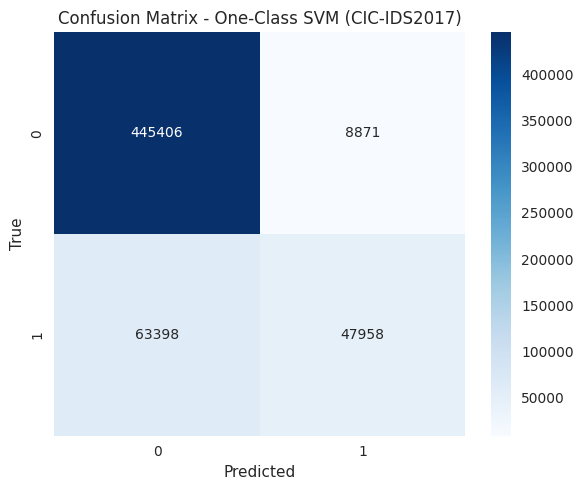

In [16]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - One-Class SVM (CIC-IDS2017)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

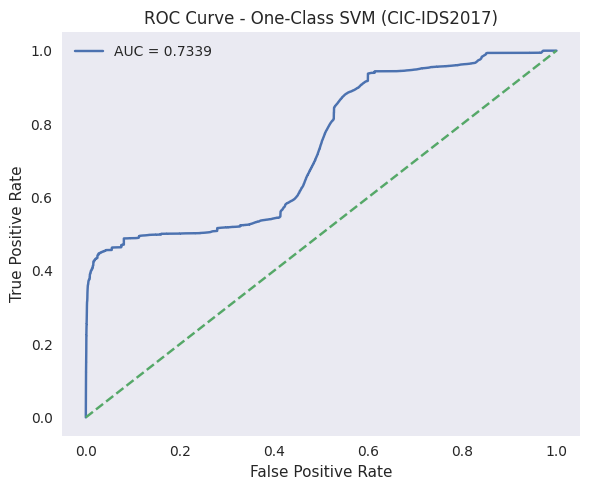

AUC: 0.7338736797654193


In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-Class SVM (CIC-IDS2017)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("AUC:", roc_auc)